<a href="https://colab.research.google.com/github/Juni0rResearcher/AdvancedRobotics/blob/main/HW5_PathPlanning_Iuzhain_Andrei_MS25_RO_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home assignment 5: Планирование пути (Path Planning)

**Student:** Андрей Южанин

**Задача:** Реализовать конвейер поиска пути в 2D пространстве, сравнив классический поиск на сетке (A*) с алгоритмами на основе случайного сэмплирования (RRT/RRT*), и выполнить постобработку траектории.

**Данные:** Среды для планирования (Occupancy Grids):
- Собственные карты: генерация Ч/Б изображения (PNG, 200x200px)

**Реализация в Jupyter/Colab:**
1. Выполнено базовое планирование (A* vs RRT):
- Реализовано два принципиально разных подхода. A* как эталон оптимальности на графе и RRT как стандарт для
систем с высокой степенью свободы.
2. Улучшенное планирование (RRT & Smoothing):
- Реализована RRT*— модификация, которая перестраивает дерево для поиска кратчайшего пути.
- Добавлен Path Smoothing: после нахождения пути прогоните его через алгоритм оптимизации (градиентное сглаживание и кривые Безье),
чтобы избавиться от «ломаных» линий.
3. Анализ и Визуализация:
- Проведены замеры по трем метрикам: длина пути, время вычислений и количество посещенных узлов/точек.
- С помощью Matplotlib отрисована карту, процесс расширения дерева/сетки и итоговый сглаженный путь.

## 1. Импорт библиотек

In [1]:
%%capture
!apt-get install ffmpeg

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
import time
from typing import List, Tuple, Optional
import heapq
from PIL import Image
import random
from dataclasses import dataclass
import warnings
warnings.filterwarnings('ignore')

## 2. Вспомогательные функции и классы

### 2.1 Загрузка и предобработка карты

Создаем класс OccupancyGrid, который представляет собой карту препятствий для планирования пути робота.

Методы класса:
- `__init__` - инициализация класса, получение карты из png изображения или из numpy массив карты
- `is_free` - роверяет, может ли робот находиться в данной клетке, не выходит ли его позиция за границы карты и нет ли в ней препятствия.
- `is_collision`- проверяет пересечение между траекторией и препятствиями
- `bresenham` - алгоритм Брезенхема, определяет какие пиксели нужно закрасить, чтобы нарисовать прямую линию между двумя точками на дискретной сетке.
- `plot` - визуализация карты.





In [3]:
class OccupancyGrid:
    """Класс для работы с occupancy grid картой"""

    def __init__(self, image_path: str = None, grid_data: np.ndarray = None, threshold: int = 127):
        """
        Загрузка карты из изображения или из массива

        Args:
            image_path: путь к PNG изображению
            grid_data: numpy массив карты (0 - свободно, 1 - препятствие)
            threshold: порог бинаризации (0-255)
        """
        if grid_data is not None:
            self.grid = grid_data
            self.height, self.width = self.grid.shape
        elif image_path is not None:
            # Загружаем изображение и конвертируем в grayscale
            img = Image.open(image_path).convert('L')
            self.width, self.height = img.size
            self.original_img = np.array(img)

            # Бинаризация: 0 - свободно, 1 - препятствие
            self.grid = (self.original_img < threshold).astype(np.uint8)

        else:
            raise ValueError("Either image_path or grid_data must be provided")

    def is_free(self, x: int, y: int) -> bool:
        """Проверка, свободна ли клетка"""
        if x < 0 or x >= self.width or y < 0 or y >= self.height:
            return False
        return self.grid[y, x] == 0

    def is_collision(self, x1: int, y1: int, x2: int, y2: int) -> bool:
        """Проверка коллизии между двумя точками"""
        # Используем алгоритм Брезенхема
        points = self.bresenham(x1, y1, x2, y2)
        for x, y in points:
            if not self.is_free(x, y):
                return True
        return False

    @staticmethod
    def bresenham(x1: int, y1: int, x2: int, y2: int) -> List[Tuple[int, int]]:
        """Алгоритм Брезенхема для получения точек на линии"""
        points = []
        dx = abs(x2 - x1)
        dy = abs(y2 - y1)
        sx = 1 if x1 < x2 else -1
        sy = 1 if y1 < y2 else -1
        err = dx - dy

        while True:
            points.append((x1, y1))
            if x1 == x2 and y1 == y2:
                break
            e2 = 2 * err
            if e2 > -dy:
                err -= dy
                x1 += sx
            if e2 < dx:
                err += dx
                y1 += sy

        return points

    def plot(self, ax=None, show_grid=True):
        """Визуализация карты"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 10))

        # Отображаем карту
        ax.imshow(1 - self.grid, cmap='gray', origin='upper')

        if show_grid:
            # Рисуем сетку
            ax.set_xticks(np.arange(-0.5, self.width, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, self.height, 1), minor=True)
            ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)

        ax.set_xlim(-0.5, self.width - 0.5)
        ax.set_ylim(self.height - 0.5, -0.5)
        ax.set_aspect('equal')
        return ax

### 2.2 Генерация тестовых карт

Метод `create_test_maps` - создает 3 карты:
- map1 - открытое пространство, с препятствием в центре
- map2 - узкий коридор с препятствием в центре
- map3 - простой лабиринт в виде сетки

In [4]:
def create_test_maps():
    """Создание тестовых карт для экспериментов"""

    # Карта 1: Простое открытое пространство
    map1 = np.zeros((200, 200), dtype=np.uint8)
    # Добавляем несколько препятствий
    map1[50:150, 80:120] = 1  # Вертикальная стена
    map1[80:120, 50:150] = 1  # Горизонтальная стена (создает лабиринт)

    # Карта 2: Узкий коридор
    map2 = np.ones((200, 200), dtype=np.uint8)
    map2[:, 80:120] = 0  # Две стены
    map2[80:120, 90:110] = 1  # Узкий проход

    # Карта 3: Лабиринт
    map3 = np.ones((200, 200), dtype=np.uint8)
    # Создаем простой лабиринт
    for i in range(0, 200, 40):
        map3[i:i+5, :] = 0
        map3[:, i:i+5] = 0

    return map1, map2, map3

### 2.3 Алгоритм A*

Создаем класс AStar, который реализует алгоритм A* для поиска пути.

Класс содержит методы:
1. `__init__` - Инициализация объекта для поиска пути
  
  Параметры:

    - grid: объект карты препятствий
  
  Атрибуты:

    - grid: ссылка на карту
    - visited_nodes: счетчик посещенных узлов (для статистики)
    - explored: список всех посещенных узлов (для визуализации процесса)

2. `heurisitc` - рассчитывает евклидовой расстояние между точками по формуле `np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)`

3. `get_neighbors` - поиск соседей, решает задачу поиска свободных соседних клеток, куда можно пройти из текущей. Алгоритм:
    - Перебирает все 8 возможных направлений, включая диагонали
    - Исключает саму текущую клетку (dx=0, dy=0)
    - Проверяет, что соседняя клетка в пределах карты
    - Проверяет, что соседняя клетка свободна и не является препятствием

4. `plan` - основной метод поиска пути. Находит оптимальный путь от старта до цели, алгоритм метода:
    
    - Проверка валидности старта и цели
    - Инициализация приоритетной очереди и структур данных
    - Цикл: извлечение узла с минимальной оценкой
    - Проверка достижения цели и восстановление пути в случае успеха
    - Исследование соседей с обновлением стоимости (g_scrore)
    - Возврат результата (путь, время, статистика)

In [5]:
class AStar:
    """Реализация A* алгоритма для поиска пути"""

    def __init__(self, grid: OccupancyGrid):
        self.grid = grid
        self.visited_nodes = 0
        self.explored = []

    def heuristic(self, a: Tuple[int, int], b: Tuple[int, int]) -> float:
        """Евклидово расстояние"""
        return np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

    def get_neighbors(self, node: Tuple[int, int]) -> List[Tuple[int, int]]:
        """Получение соседних клеток"""
        neighbors = []
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                nx, ny = node[0] + dx, node[1] + dy
                if 0 <= nx < self.grid.width and 0 <= ny < self.grid.height:
                    if self.grid.is_free(nx, ny):
                        neighbors.append((nx, ny))
        return neighbors

    def plan(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Tuple[Optional[List[Tuple[int, int]]], float, int]:
        """
        Поиск пути алгоритмом A*

        Returns:
            path: список точек пути
            time: время выполнения
            visited: количество посещенных узлов
        """
        start_time = time.time()

        # Проверка старта и цели
        if not self.grid.is_free(start[0], start[1]):
            print(f"Стартовая точка {start} находится в препятствии!")
            return None, time.time() - start_time, 0

        if not self.grid.is_free(goal[0], goal[1]):
            print(f"Целевая точка {goal} находится в препятствии!")
            return None, time.time() - start_time, 0

        # Инициализация
        open_set = []
        heapq.heappush(open_set, (0, start))

        came_from = {}
        g_score = {start: 0}
        f_score = {start: self.heuristic(start, goal)}

        self.visited_nodes = 0
        self.explored = []

        while open_set:
            current = heapq.heappop(open_set)[1]
            self.explored.append(current)
            self.visited_nodes += 1

            if current == goal:
                # Восстановление пути
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                path.reverse()

                elapsed_time = time.time() - start_time
                return path, elapsed_time, self.visited_nodes

            for neighbor in self.get_neighbors(current):
                # Стоимость перемещения (Евклидово расстояние)
                tentative_g = g_score[current] + np.sqrt((current[0] - neighbor[0])**2 +
                                                          (current[1] - neighbor[1])**2)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        elapsed_time = time.time() - start_time
        print("A* не нашел путь!")
        return None, elapsed_time, self.visited_nodes

### 2.4 Реализация алгоритм RRT*



Класс `RRTStar` реализует **RRT*** (Rapidly-exploring Random Tree Star) — улучшенную версию алгоритма RRT, которая обеспечивает асимптотическую оптимальность пути. Алгоритм строит дерево, случайным образом исследуя пространство, и постоянно улучшает найденные пути через процедуру переподключения соседей.

Методы класса:
1. `__init__` - инициализация алгоритма и настройка параметров:
      - grid - Карта препятствий
      - step_size - Максимальное расстояние между узлами
      - max_iterations - Максимальное количество итераций
      - goal_sample_rate - Вероятность выбрать цель вместо случайной точки
      - radius - радиус поиска соседей для оптимизации

2. `random_point` - равномерное исследование пространства за счет случайных семплов

3. `nearest_node` - найти узел в существующем дереве, который находится ближе всего к случайно сгенерированной точке

4. `steer` - создание новой точки в направлении цели с ограничением по расстоянию

5. `is_collision_free` - проверка отсутствия препятствий между двумя точками

6. `near_nodes` - поиск всех узлов в заданном радиусе от текущего узла

7. `plan` - Основной метод поиска пути (ядро алгоритма RRT*)

Ключевые особенности RRT* в сравнении с RRT

|Особенность	| RRT	| RRT* |
| --------| ----|------|
|Выбор родителя	| Ближайший узел	|Лучший узел среди соседей |
|Оптимизация пути |	Нет	| Переподключение соседей
|Асимптотическая оптимальность|	Нет	|Да (с увеличением итераций) |
|Сложность на итерацию|	O(N)	|O(N log N)|


In [6]:
@dataclass
class Node:
    """Узел дерева RRT/RRT*"""
    x: float
    y: float
    parent: Optional['Node'] = None
    cost: float = 0.0

class RRTStar:
    """Реализация RRT* алгоритма"""

    def __init__(self, grid: OccupancyGrid, step_size: float = 5.0,
                 max_iterations: int = 5000, goal_sample_rate: float = 0.1,
                 radius: float = 15.0):
        self.grid = grid
        self.step_size = step_size
        self.max_iterations = max_iterations
        self.goal_sample_rate = goal_sample_rate
        self.radius = radius
        self.nodes = []
        self.explored = []
        self.edges = []

    def random_point(self) -> Tuple[float, float]:
        """Генерация случайной точки"""
        return (random.uniform(0, self.grid.width),
                random.uniform(0, self.grid.height))

    def nearest_node(self, point: Tuple[float, float]) -> Node:
        """Поиск ближайшего узла"""
        min_dist = float('inf')
        nearest = None
        for node in self.nodes:
            dist = np.sqrt((node.x - point[0])**2 + (node.y - point[1])**2)
            if dist < min_dist:
                min_dist = dist
                nearest = node
        return nearest

    def steer(self, from_node: Node, to_point: Tuple[float, float]) -> Tuple[float, float]:
        """Создание новой точки в направлении цели"""
        dx = to_point[0] - from_node.x
        dy = to_point[1] - from_node.y
        dist = np.sqrt(dx**2 + dy**2)

        if dist < self.step_size:
            return to_point
        else:
            return (from_node.x + dx / dist * self.step_size,
                    from_node.y + dy / dist * self.step_size)

    def is_collision_free(self, node1: Node, node2: Tuple[float, float]) -> bool:
        """Проверка отсутствия коллизий между двумя точками"""
        x1, y1 = int(node1.x), int(node1.y)
        x2, y2 = int(node2[0]), int(node2[1])

        if not (0 <= x1 < self.grid.width and 0 <= y1 < self.grid.height and
                0 <= x2 < self.grid.width and 0 <= y2 < self.grid.height):
            return False

        return not self.grid.is_collision(x1, y1, x2, y2)

    def near_nodes(self, node: Node) -> List[Node]:
        """Поиск узлов в радиусе (для RRT*)"""
        near = []
        for n in self.nodes:
            dist = np.sqrt((n.x - node.x)**2 + (n.y - node.y)**2)
            if dist < self.radius:
                near.append(n)
        return near

    def plan(self, start: Tuple[float, float], goal: Tuple[float, float]) -> Tuple[Optional[List[Tuple[float, float]]], float, int]:
        """Поиск пути алгоритмом RRT*"""
        start_time = time.time()

        # Проверка старта и цели
        if not self.grid.is_free(int(start[0]), int(start[1])):
            print(f"Стартовая точка {start} находится в препятствии!")
            self.edges = self.explored.copy()
            return None, time.time() - start_time, 0

        if not self.grid.is_free(int(goal[0]), int(goal[1])):
            print(f"Целевая точка {goal} находится в препятствии!")
            self.edges = self.explored.copy()
            return None, time.time() - start_time, 0

        # Инициализация
        start_node = Node(start[0], start[1])
        goal_node = Node(goal[0], goal[1])
        self.nodes = [start_node]
        self.explored = []

        path_found = False
        final_node = None

        for i in range(self.max_iterations):
            # Выбор точки назначения
            if random.random() < self.goal_sample_rate:
                sample = (goal[0], goal[1])
            else:
                sample = self.random_point()

            # Находим ближайший узел
            nearest = self.nearest_node(sample)

            # Создаем новую точку
            new_point = self.steer(nearest, sample)

            # Проверка коллизий
            if not self.is_collision_free(nearest, new_point):
                continue

            # Создаем новый узел
            new_node = Node(new_point[0], new_point[1])

            # RRT*: Поиск лучшего родителя
            near_nodes_list = self.near_nodes(new_node)
            min_cost = nearest.cost + np.sqrt((new_node.x - nearest.x)**2 +
                                              (new_node.y - nearest.y)**2)
            best_parent = nearest

            for near_node in near_nodes_list:
                if self.is_collision_free(near_node, (new_node.x, new_node.y)):
                    cost = near_node.cost + np.sqrt((new_node.x - near_node.x)**2 +
                                                    (new_node.y - near_node.y)**2)
                    if cost < min_cost:
                        min_cost = cost
                        best_parent = near_node

            # Устанавливаем родителя
            new_node.parent = best_parent
            new_node.cost = min_cost

            # RRT*: Переподключение соседей
            for near_node in near_nodes_list:
                if near_node != best_parent and self.is_collision_free(new_node, (near_node.x, near_node.y)):
                    new_cost = new_node.cost + np.sqrt((near_node.x - new_node.x)**2 +
                                                        (near_node.y - new_node.y)**2)
                    if new_cost < near_node.cost:
                        near_node.parent = new_node
                        near_node.cost = new_cost

            self.nodes.append(new_node)
            self.explored.append((nearest.x, nearest.y, new_node.x, new_node.y))

            # Проверка достижения цели
            dist_to_goal = np.sqrt((new_node.x - goal[0])**2 + (new_node.y - goal[1])**2)
            if dist_to_goal < self.step_size:
                if self.is_collision_free(new_node, goal):
                    goal_node.parent = new_node
                    goal_node.cost = new_node.cost + dist_to_goal
                    self.nodes.append(goal_node)
                    final_node = goal_node
                    path_found = True
                    break

        self.edges = self.explored.copy()

        if path_found:
            # Восстановление пути
            path = []
            current = final_node
            while current is not None:
                path.append((current.x, current.y))
                current = current.parent
            path.reverse()

            elapsed_time = time.time() - start_time
            return path, elapsed_time, len(self.nodes)

        elapsed_time = time.time() - start_time
        print(f"RRT* не нашел путь за {self.max_iterations} итераций!")
        return None, elapsed_time, len(self.nodes)

### 2.5 Сглаживание траектории



Класс `PathSmoother` предоставляет методы для постобработки найденных путей, удаляя изломанность и создавая более естественные, гладкие траектории. Это критически важно для реальных роботов, так как резкие повороты и угловатые пути могут быть невыполнимы из-за кинематических ограничений.

Методы:
1. `gradient_smoothing` - выполняет итеративное сглаживание пути с учетом препятствий путем оптимизации позиций точек.

    **Принцип работы:**  Метод имитирует физический процесс, где точки пути соединены пружинами (сила сглаживания) и отталкиваются от препятствий (сила отталкивания).

    **Алгоритм работы:**

    a. Копируем исходный путь

    b. Для каждой внутренней точки (исключая начало и конец):
      - Вычисляем силу сглаживания от соседних точек
      - Если точка попала в препятствие, то добавляем силу отталкивания
      - Обновляем позицию точки
    c. Повторяем iterations раз

2. `bezier_smoothing` - Сглаживание кривыми Безье,аппроксимация пути с помощью кубических кривых Безье для создания плавной траектории.

    **Принцип работы:** Метод аппроксимирует путь с помощью кубических кривых Безье, которые гарантируют математическую гладкость. Кубическая кривая Безье определяется 4 контрольными точками:
    - P0: Начальная точка
    - P1, P2: Контрольные точки (определяют форму)
    - P3: Конечная точка

    **Формула:**
    ```
    B(t) = (1-t)³·P0 + 3(1-t)²·t·P1 + 3(1-t)·t²·P2 + t³·P3
    ```
    где t ∈ [0, 1]
    
    **Стратегия:** Для внутренних сегментов берутся контрольные точки как средние между соседними опорными точками. Это обеспечивает непрерывность первой производной (гладкое соединение). Начало и конец пути фиксированы (P1=P0, P2=P3 для крайних сегментов).




In [7]:
class PathSmoother:
    """Класс для сглаживания траектории"""

    @staticmethod
    def gradient_smoothing(path: List[Tuple[float, float]],
                          grid: OccupancyGrid,
                          alpha: float = 0.5,
                          beta: float = 0.3,
                          iterations: int = 100) -> List[Tuple[float, float]]:
        """Градиентное сглаживание пути"""
        if not path or len(path) < 3:
            return path

        smoothed = [list(p) for p in path]

        for _ in range(iterations):
            for i in range(1, len(smoothed) - 1):
                # Сила сглаживания
                smooth_x = smoothed[i-1][0] + smoothed[i+1][0] - 2 * smoothed[i][0]
                smooth_y = smoothed[i-1][1] + smoothed[i+1][1] - 2 * smoothed[i][1]

                # Проверка на коллизии
                x, y = int(smoothed[i][0]), int(smoothed[i][1])
                if 0 <= x < grid.width and 0 <= y < grid.height:
                    if not grid.is_free(x, y):
                        # Если точка в препятствии, отталкиваем
                        grad_x, grad_y = 0, 0
                        for dx in [-1, 0, 1]:
                            for dy in [-1, 0, 1]:
                                nx, ny = x + dx, y + dy
                                if 0 <= nx < grid.width and 0 <= ny < grid.height:
                                    if not grid.is_free(nx, ny):
                                        grad_x += dx
                                        grad_y += dy
                        smoothed[i][0] += beta * grad_x
                        smoothed[i][1] += beta * grad_y

                # Применяем сглаживание
                smoothed[i][0] += alpha * smooth_x
                smoothed[i][1] += alpha * smooth_y

        # Ограничиваем координаты в пределах карты
        for i in range(len(smoothed)):
            smoothed[i][0] = max(0, min(smoothed[i][0], grid.width - 1))
            smoothed[i][1] = max(0, min(smoothed[i][1], grid.height - 1))

        return [(p[0], p[1]) for p in smoothed]

    @staticmethod
    def bezier_smoothing(path: List[Tuple[float, float]],
                         num_points: int = 100) -> List[Tuple[float, float]]:
        """Сглаживание с помощью кривых Безье"""
        if not path or len(path) < 2:
            return path

        smoothed = []

        for i in range(len(path) - 1):
            p0 = path[i]
            p3 = path[i + 1]

            # Контрольные точки
            if i > 0:
                p1 = ((p0[0] + path[i-1][0]) / 2, (p0[1] + path[i-1][1]) / 2)
            else:
                p1 = p0

            if i < len(path) - 2:
                p2 = ((p3[0] + path[i+2][0]) / 2, (p3[1] + path[i+2][1]) / 2)
            else:
                p2 = p3

            # Генерация кривой Безье
            steps = max(2, num_points // len(path))
            for t in np.linspace(0, 1, steps):
                # Кубическая кривая Безье
                x = (1-t)**3 * p0[0] + 3*(1-t)**2*t * p1[0] + 3*(1-t)*t**2 * p2[0] + t**3 * p3[0]
                y = (1-t)**3 * p0[1] + 3*(1-t)**2*t * p1[1] + 3*(1-t)*t**2 * p2[1] + t**3 * p3[1]
                smoothed.append((x, y))

        return smoothed

### 2.6 Функция выбора карты

In [21]:
def map_selection (selected_map = 'map_open.png'):

    print(f"\nЗагрузка карты: {selected_map}")
    print(f"Сценарий: {test_scenarios[selected_map]['description']}")

    grid = OccupancyGrid(selected_map, threshold=127)

    start = test_scenarios[selected_map]['start']
    goal = test_scenarios[selected_map]['goal']

    print(f"Старт: {start}")
    print(f"Цель: {goal}")

    # Проверяем, находятся ли точки в свободном пространстве
    if grid.is_free(start[0], start[1]):
        print(f"Стартовая точка задана верно!")
    else:
        print(f"Стартовая точка находится в препятствии! Измените координаты!")

    if grid.is_free(goal[0], goal[1]):
        print(f"Целевая точка задана верно!")
    else:
        print(f"Целевая точка находится в препятствии! Измените координаты!")

    return grid, start, goal

### 2.7 Визуализация

Класс `PathPlanningAnalyzer` решает следующие задачи:

- Планирование пути: Запуск детерминированного (A*) и вероятностного (RRT*) алгоритмов.
- Оптимизация траектории: Сглаживание путей методами градиентного спуска и кривых Безье.
- Сбор метрик: Расчет времени работы, количества узлов, длины пути.
- Визуализация: Построение графиков путей и сравнительных таблиц.

Методы:

1. `run_experiment`:
    - Запуск A:* Создает экземпляр AStar, планирует путь, замеряет время и количество проверенных узлов.
    - Запуск RRT:* Создает экземпляр RRTStar (с параметрами step_size, max_iterations), планирует путь.
    - Cглаживание с gradient_smoothing и bezier_smoothing
    - Вычислиение длины пути
    - Сохранение всех данных (пути, время, узлы, длины, статус успеха) в self.results.

2. `visualize` - графическое представление результатов, рисует график:
    - A* визуализация
    - траектория A* со сглажеванием
    - RRT* визуализация
    - траектория RRT* со сглаживанием
    - Визуализация деревьев RRT*
    - Сравнительная таблица

In [8]:
class PathPlanningAnalyzer:
    """Класс для анализа и сравнения алгоритмов"""

    def __init__(self, grid: OccupancyGrid):
        self.grid = grid
        self.results = {}

    def run_experiment(self, start: Tuple[int, int], goal: Tuple[int, int]):
        """Запуск всех алгоритмов и сбор метрик"""

        # A*
        print("Запуск A*...")
        astar = AStar(self.grid)
        path_a, time_a, nodes_a = astar.plan(start, goal)

        # RRT*
        print("Запуск RRT*...")
        rrt_star = RRTStar(self.grid, step_size=5.0, max_iterations=5000)
        path_rrt, time_rrt, nodes_rrt = rrt_star.plan(start, goal)

        # Сглаживание
        print("Сглаживание путей...")
        smoother = PathSmoother()

        path_a_smooth = None
        path_a_bezier = None
        path_rrt_smooth = None
        path_rrt_bezier = None

        if path_a:
            path_a_smooth = smoother.gradient_smoothing(path_a, self.grid)
            path_a_bezier = smoother.bezier_smoothing(path_a)

        if path_rrt:
            path_rrt_smooth = smoother.gradient_smoothing(path_rrt, self.grid)
            path_rrt_bezier = smoother.bezier_smoothing(path_rrt)

        # Расчет длин путей
        def path_length(path):
            if not path:
                return float('inf')
            length = 0
            for i in range(len(path) - 1):
                length += np.sqrt((path[i][0] - path[i+1][0])**2 +
                                 (path[i][1] - path[i+1][1])**2)
            return length

        self.results = {
            'A*': {
                'path': path_a,
                'path_smooth': path_a_smooth,
                'path_bezier': path_a_bezier,
                'time': time_a,
                'nodes': nodes_a,
                'length': path_length(path_a),
                'length_smooth': path_length(path_a_smooth) if path_a_smooth else None,
                'found': path_a is not None
            },
            'RRT*': {
                'path': path_rrt,
                'path_smooth': path_rrt_smooth,
                'path_bezier': path_rrt_bezier,
                'time': time_rrt,
                'nodes': nodes_rrt,
                'length': path_length(path_rrt),
                'length_smooth': path_length(path_rrt_smooth) if path_rrt_smooth else None,
                'found': path_rrt is not None
            }
        }

        self.results['rrt_edges'] = rrt_star.edges

        return self.results

    def visualize(self, start: Tuple[int, int], goal: Tuple[int, int]):
        """Визуализация результатов"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # A* визуализация
        ax1 = axes[0, 0]
        self.grid.plot(ax1, show_grid=False)
        if self.results['A*']['found'] and self.results['A*']['path']:
            path = np.array(self.results['A*']['path'])
            ax1.plot(path[:, 0], path[:, 1], 'b-', linewidth=2, label='A* Path')
        ax1.plot(start[0], start[1], 'go', markersize=10, label='Start')
        ax1.plot(goal[0], goal[1], 'ro', markersize=10, label='Goal')

        length_text = f"{self.results['A*']['length']:.2f}" if self.results['A*']['found'] else "Not found"
        ax1.set_title(f'A* Path\nLength: {length_text}, Time: {self.results["A*"]["time"]:.3f}s')
        ax1.legend()

        # A* сглаженный
        ax2 = axes[0, 1]
        self.grid.plot(ax2, show_grid=False)
        if self.results['A*']['found']:
            if self.results['A*']['path_smooth']:
                path_s = np.array(self.results['A*']['path_smooth'])
                ax2.plot(path_s[:, 0], path_s[:, 1], 'g-', linewidth=2, label='Smoothed')
            if self.results['A*']['path_bezier']:
                path_b = np.array(self.results['A*']['path_bezier'])
                ax2.plot(path_b[:, 0], path_b[:, 1], 'r--', linewidth=1.5, label='Bezier')
        ax2.plot(start[0], start[1], 'go', markersize=10)
        ax2.plot(goal[0], goal[1], 'ro', markersize=10)

        smooth_text = f"{self.results['A*']['length_smooth']:.2f}" if self.results['A*']['length_smooth'] else "N/A"
        ax2.set_title(f'A* Smoothed\nLength: {smooth_text}')
        ax2.legend()

        # RRT* визуализация
        ax3 = axes[0, 2]
        self.grid.plot(ax3, show_grid=False)
        if self.results['RRT*']['found'] and self.results['RRT*']['path']:
            path = np.array(self.results['RRT*']['path'])
            ax3.plot(path[:, 0], path[:, 1], 'b-', linewidth=2, label='RRT* Path')
        ax3.plot(start[0], start[1], 'go', markersize=10)
        ax3.plot(goal[0], goal[1], 'ro', markersize=10)

        length_text = f"{self.results['RRT*']['length']:.2f}" if self.results['RRT*']['found'] else "Not found"
        ax3.set_title(f'RRT* Path\nLength: {length_text}, Time: {self.results["RRT*"]["time"]:.3f}s')
        ax3.legend()

        # RRT* сглаженный
        ax4 = axes[1, 0]
        self.grid.plot(ax4, show_grid=False)
        if self.results['RRT*']['found']:
            if self.results['RRT*']['path_smooth']:
                path_s = np.array(self.results['RRT*']['path_smooth'])
                ax4.plot(path_s[:, 0], path_s[:, 1], 'g-', linewidth=2, label='Smoothed')
            if self.results['RRT*']['path_bezier']:
                path_b = np.array(self.results['RRT*']['path_bezier'])
                ax4.plot(path_b[:, 0], path_b[:, 1], 'r--', linewidth=1.5, label='Bezier')
        ax4.plot(start[0], start[1], 'go', markersize=10)
        ax4.plot(goal[0], goal[1], 'ro', markersize=10)

        smooth_text = f"{self.results['RRT*']['length_smooth']:.2f}" if self.results['RRT*']['length_smooth'] else "N/A"
        ax4.set_title(f'RRT* Smoothed\nLength: {smooth_text}')
        ax4.legend()

        # Визуализация деревьев RRT*
        ax5 = axes[1, 1]
        self.grid.plot(ax5, show_grid=False)
        rrt_edges = self.results.get('rrt_edges', [])
        if not rrt_edges and self.results['RRT*']['found']:
            ax5.text(0.5, 0.5, 'Tree data not saved\nin results', transform=ax5.transAxes,
                     ha='center', va='center', color='gray', fontsize=12)
        else:
            for edge in rrt_edges:
                ax5.plot([edge[0], edge[2]], [edge[1], edge[3]], 'b-', alpha=0.3, linewidth=0.5)

        ax5.plot(start[0], start[1], 'go', markersize=10)
        ax5.plot(goal[0], goal[1], 'ro', markersize=10)
        ax5.set_title('RRT* Tree Visualization')

        # Сравнительная таблица
        ax6 = axes[1, 2]
        ax6.axis('off')

        a_found = self.results['A*']['found']
        rrt_found = self.results['RRT*']['found']

        metrics_data = [
            ['Metric', 'A*', 'RRT*'],
            ['Path Found', '+' if a_found else '-', '+' if rrt_found else '-'],
            ['Time (s)', f'{self.results["A*"]["time"]:.3f}', f'{self.results["RRT*"]["time"]:.3f}'],
            ['Nodes/Points', f'{self.results["A*"]["nodes"]}', f'{self.results["RRT*"]["nodes"]}'],
            ['Path Length', f'{self.results["A*"]["length"]:.2f}' if a_found else 'N/A',
             f'{self.results["RRT*"]["length"]:.2f}' if rrt_found else 'N/A'],
            ['Smoothed Length', f'{self.results["A*"]["length_smooth"]:.2f}' if self.results["A*"]["length_smooth"] else 'N/A',
             f'{self.results["RRT*"]["length_smooth"]:.2f}' if self.results["RRT*"]["length_smooth"] else 'N/A']
        ]

        table = ax6.table(cellText=metrics_data, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5)
        ax6.set_title('Comparison Metrics', pad=20)

        plt.tight_layout()
        plt.show()

    def animate_rrt(self, start: Tuple[int, int], goal: Tuple[int, int],
                filename: str = 'rrt_animation.mp4', fps: int = 20):
            """
            Создание анимации процесса поиска пути алгоритмом RRT*

            Args:
                start: Стартовая точка (x, y)
                goal: Целевая точка (x, y)
                filename: Имя файла для сохранения анимации
                fps: Количество кадров в секунду
            """
            from matplotlib.animation import FuncAnimation, PillowWriter
            import matplotlib.pyplot as plt

            # Проверяем, есть ли данные для анимации
            if 'RRT*' not in self.results or not self.results['RRT*']['found']:
                print("Нет данных для анимации! Запустите experiment сначала.")
                return

            # Получаем рёбра дерева из explored (сохраняются в RRTStar.plan)
            # Формат: (x1, y1, x2, y2) - координаты ребра
            edges = self.results.get('rrt_edges', [])

            if not edges:
                print("Данные рёбер не сохранены! Необходимо модифицировать RRTStar.plan")
                return

            # Создаем фигуру для анимации
            fig, ax = plt.subplots(figsize=(10, 10))

            # Инициализация элементов
            ax.imshow(1 - self.grid.grid, cmap='gray', origin='upper')
            ax.set_xlim(-0.5, self.grid.width - 0.5)
            ax.set_ylim(self.grid.height - 0.5, -0.5)
            ax.set_aspect('equal')
            ax.set_title('RRT* Path Planning')

            # Точки старта и цели
            ax.plot(start[0], start[1], 'go', markersize=12, label='Start', zorder=5)
            ax.plot(goal[0], goal[1], 'ro', markersize=12, label='Goal', zorder=5)

            # Элементы для анимации
            tree_lines = []
            path_line, = ax.plot([], [], 'g-', linewidth=2, label='Path', zorder=4)

            # Функция инициализации
            def init():
                path_line.set_data([], [])
                return tree_lines + [path_line]

            # Функция обновления кадра
            def update(frame):
                # Очищаем предыдущие линии дерева
                for line in tree_lines:
                    line.remove()
                tree_lines.clear()

                # Рисуем рёбра до текущего кадра
                for i in range(min(frame + 1, len(edges))):
                    edge = edges[i]
                    line, = ax.plot([edge[0], edge[2]], [edge[1], edge[3]],
                                  'b-', alpha=0.3, linewidth=0.5)
                    tree_lines.append(line)

                # Если путь найден, рисуем его
                if self.results['RRT*']['path']:
                    path = self.results['RRT*']['path']
                    path_x = [p[0] for p in path]
                    path_y = [p[1] for p in path]
                    path_line.set_data(path_x, path_y)

                ax.set_title(f'RRT* Planning - Iteration {frame + 1}/{len(edges)}')
                return tree_lines + [path_line]

            # Создаем анимацию
            anim = FuncAnimation(fig, update, frames=len(edges),
                                init_func=init, blit=True, interval=50)

            # Сохраняем анимацию
            try:
                if filename.endswith('.gif'):
                    anim.save(filename, writer=PillowWriter(fps=fps))
                else:
                    anim.save(filename, writer='ffmpeg', fps=fps)
                print(f"Анимация сохранена: {filename}")
            except Exception as e:
                print(f"Ошибка сохранения анимации: {e}")
                print("Попробуйте установить ffmpeg или сохранить как GIF")

            plt.close(fig)
            return anim


### 2.8 Сохранение анимации

In [9]:
def animate_rrt(self, start: Tuple[int, int], goal: Tuple[int, int],
                filename: str = 'rrt_animation.mp4', fps: int = 20):
    """Создание анимации процесса поиска пути алгоритмом RRT*"""
    from matplotlib.animation import FuncAnimation, PillowWriter
    import matplotlib.pyplot as plt

    # Проверяем, есть ли данные для анимации
    if 'RRT*' not in self.results or not self.results['RRT*']['found']:
        print("Нет данных для анимации! Запустите experiment сначала.")
        return

    edges = self.results.get('rrt_edges', [])

    if not edges:
        print("Данные рёбер не сохранены! Необходимо модифицировать RRTStar.plan")
        return

    # Создаем фигуру для анимации
    fig, ax = plt.subplots(figsize=(10, 10))

    # Инициализация элементов
    ax.imshow(1 - self.grid.grid, cmap='gray', origin='upper')
    ax.set_xlim(-0.5, self.grid.width - 0.5)
    ax.set_ylim(self.grid.height - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_title('RRT* Path Planning')

    # Точки старта и цели
    ax.plot(start[0], start[1], 'go', markersize=12, label='Start', zorder=5)
    ax.plot(goal[0], goal[1], 'ro', markersize=12, label='Goal', zorder=5)

    # Элементы для анимации
    tree_lines = []
    path_line, = ax.plot([], [], 'g-', linewidth=2, label='Path', zorder=4)

    # Функция инициализации
    def init():
        path_line.set_data([], [])
        return tree_lines + [path_line]

    # Функция обновления кадра
    def update(frame):
        # Очищаем предыдущие линии дерева
        for line in tree_lines:
            line.remove()
        tree_lines.clear()

        # Рисуем рёбра до текущего кадра
        for i in range(min(frame + 1, len(edges))):
            edge = edges[i]
            line, = ax.plot([edge[0], edge[2]], [edge[1], edge[3]],
                          'b-', alpha=0.3, linewidth=0.5)
            tree_lines.append(line)

        # Если путь найден, рисуем его
        if self.results['RRT*']['path']:
            path = self.results['RRT*']['path']
            path_x = [p[0] for p in path]
            path_y = [p[1] for p in path]
            path_line.set_data(path_x, path_y)

        ax.set_title(f'RRT* Planning - Iteration {frame + 1}/{len(edges)}')
        return tree_lines + [path_line]

    # Создаем анимацию
    anim = FuncAnimation(fig, update, frames=len(edges),
                        init_func=init, blit=True, interval=50)

    # Сохраняем анимацию
    try:
        if filename.endswith('.gif'):
            anim.save(filename, writer=PillowWriter(fps=fps))
        else:
            anim.save(filename, writer='ffmpeg', fps=fps)
        print(f"Анимация сохранена: {filename}")
    except Exception as e:
        print(f"Ошибка сохранения анимации: {e}")
        print("Попробуйте установить ffmpeg или сохранить как GIF")

    plt.close(fig)
    return anim

## 3. Запуск проекта

### 3.1 Генерация тестовых карт

In [10]:
# Создаем тестовые карты
print("Создание тестовых карт...")
map1, map2, map3 = create_test_maps()

# Сохраняем карты как изображения
Image.fromarray((1 - map1) * 255).save('map_open.png')
Image.fromarray((1 - map2) * 255).save('map_corridor.png')
Image.fromarray((1 - map3) * 255).save('map_maze.png')

Создание тестовых карт...


### 3.2 Создание сценариев для тестирования и загрузка карты

По умолчанию создается 3 карты:

- map_open.png - открытое пространство с препятствием
- map_corridor.png - узкий корридор с препятствием
- map_maze.png - простой лабиринт в виде сетки

In [24]:
test_scenarios = {
        'map_open.png': {
            'start': (30, 30),
            'goal': (170, 170),
            'description': 'Открытое пространство с препятствиями'
        },
        'map_corridor.png': {
            'start': (100, 30),  # Верхняя часть узкого коридора
            'goal': (100, 170),   # Нижняя часть узкого коридора
            'description': 'Узкий вертикальный коридор'
        },
        'map_maze.png': {
            'start': (2, 2),
            'goal': (163, 163),
            'description': 'Лабиринт'
        }
    }

### 3.3 Запуск эксперимента

#### 3.3.1 Тест с картой 1 - открытое пространство с препятствием


Загрузка карты: map_open.png
Сценарий: Открытое пространство с препятствиями
Старт: (30, 30)
Цель: (170, 170)
Стартовая точка задана верно!
Целевая точка задана верно!
Запуск A*...
Запуск RRT*...
Сглаживание путей...

Визуализация результатов...


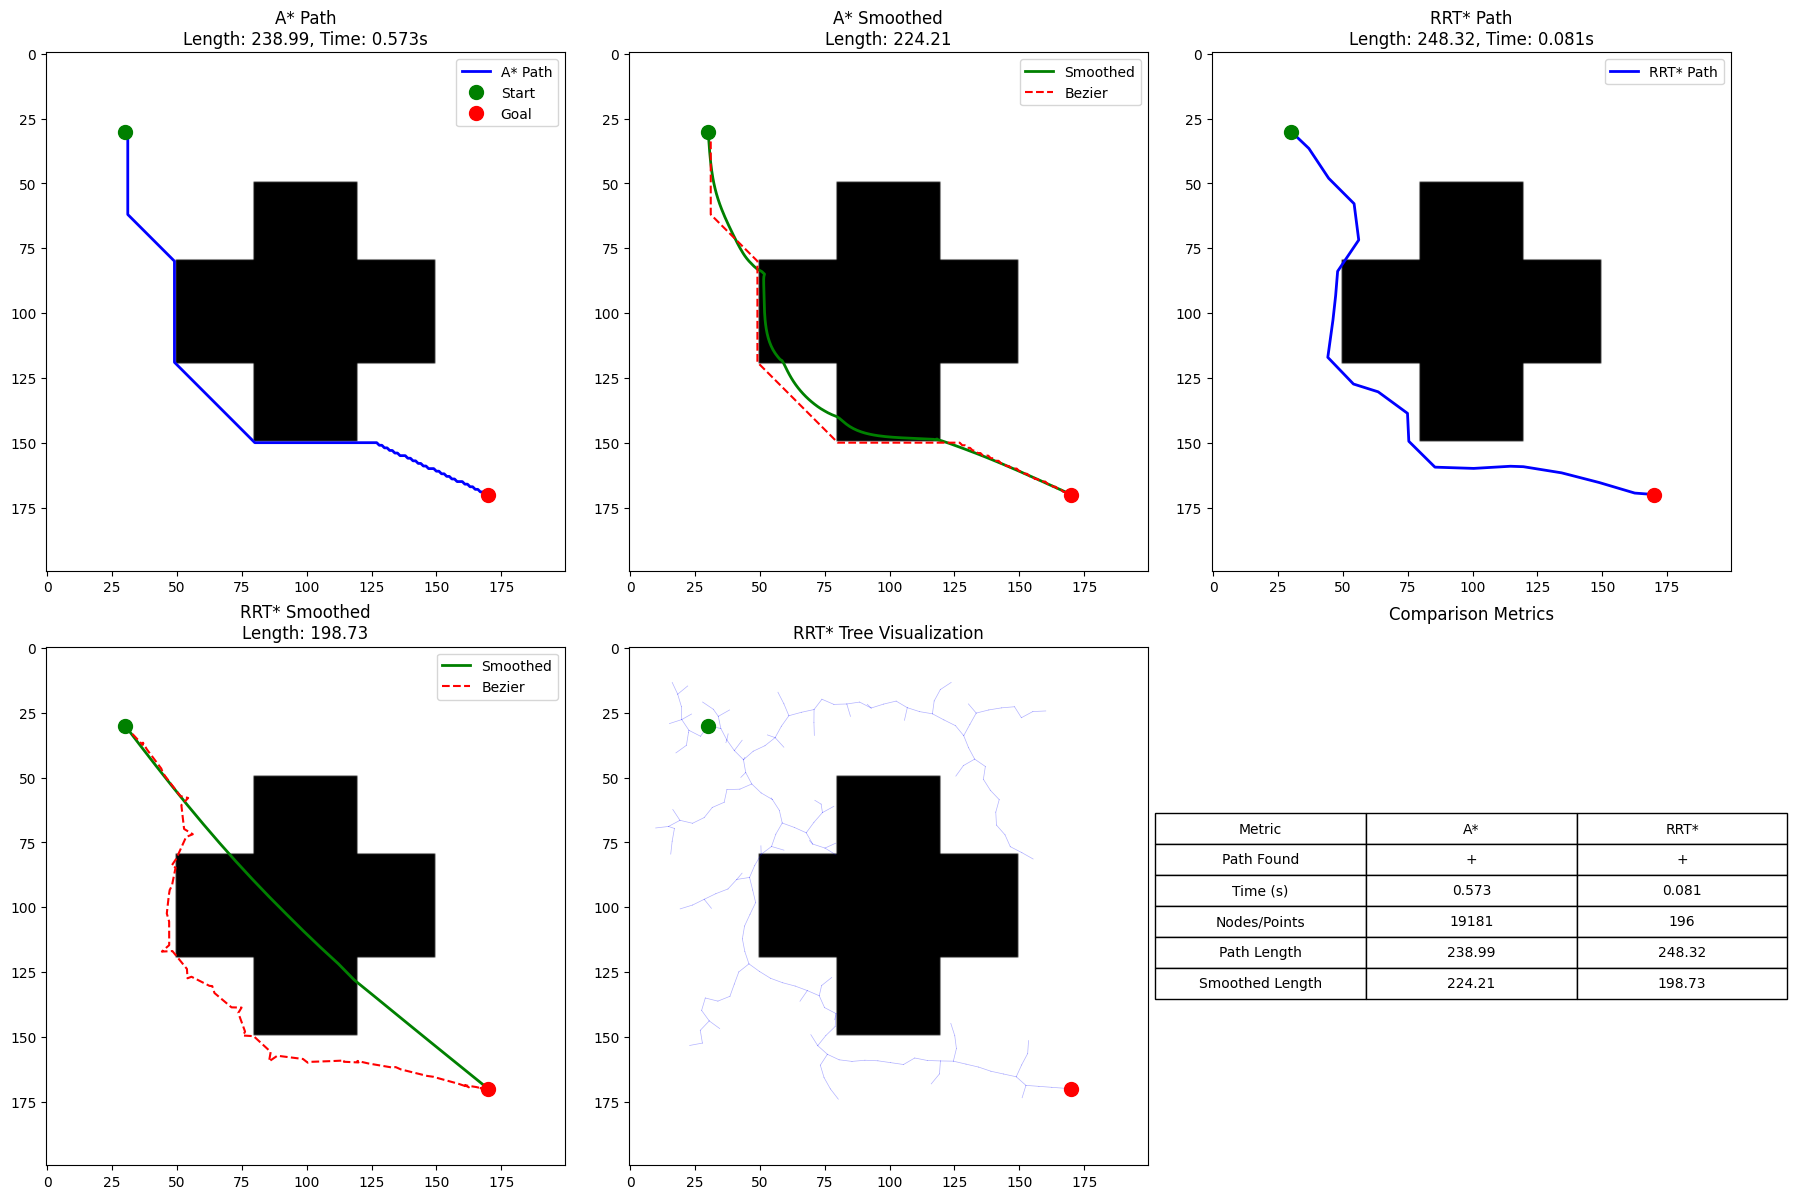

In [22]:
# Запускаем эксперимент
grid, start, goal = map_selection(selected_map= 'map_open.png')

analyzer = PathPlanningAnalyzer(grid)
results = analyzer.run_experiment(start, goal)

# Визуализация результатов
print("\nВизуализация результатов...")
analyzer.visualize(start, goal)

In [14]:
print("\nСоздание анимации...")
analyzer.animate_rrt(start, goal, filename='exp1_rrt_animation.gif', fps=15)


Создание анимации...
Анимация сохранена: rrt_animation.gif


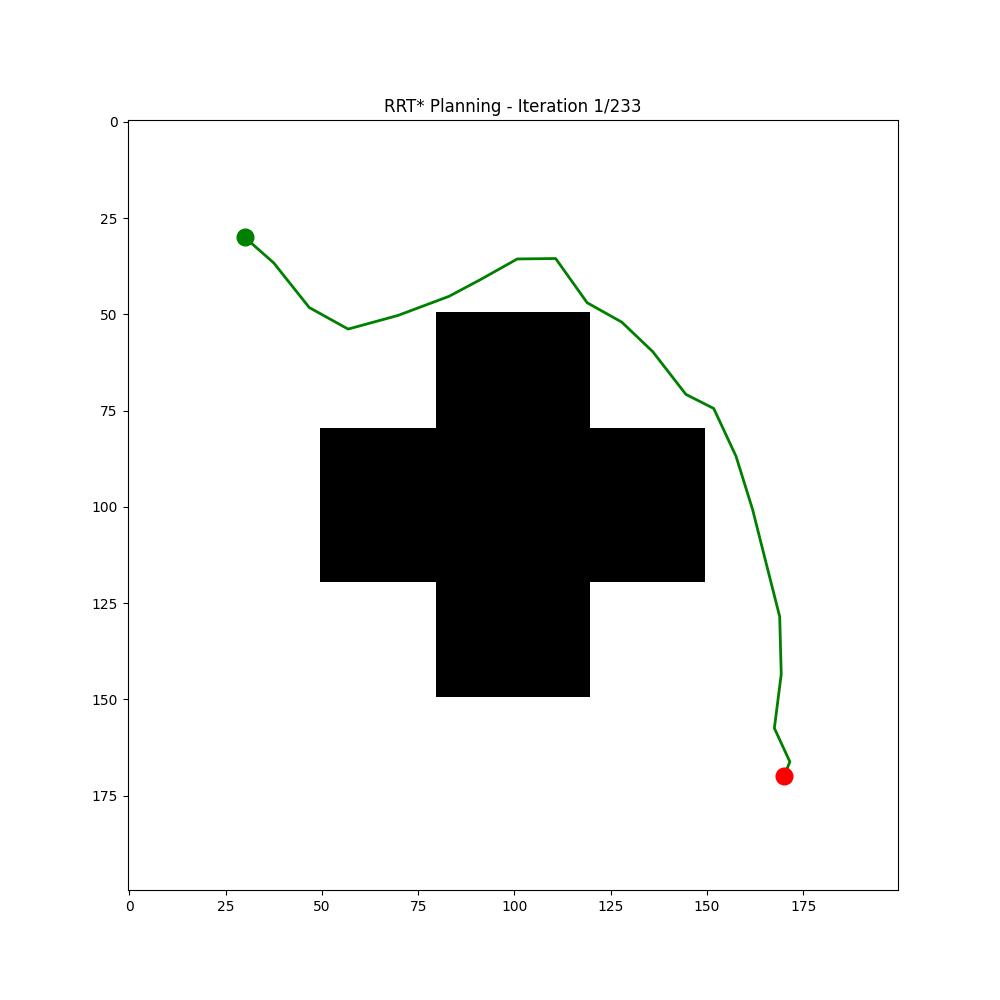

In [23]:
from IPython.display import Image as ImageIpython
from IPython.display import display
display(ImageIpython(filename='exp1_rrt_animation.gif'))

#### 3.3.2 Тест с картой 2 - корридор с препятствием


Загрузка карты: map_maze.png
Сценарий: Лабиринт
Старт: (2, 2)
Цель: (163, 163)
Стартовая точка задана верно!
Целевая точка задана верно!
Запуск A*...
Запуск RRT*...
Сглаживание путей...

Визуализация результатов...


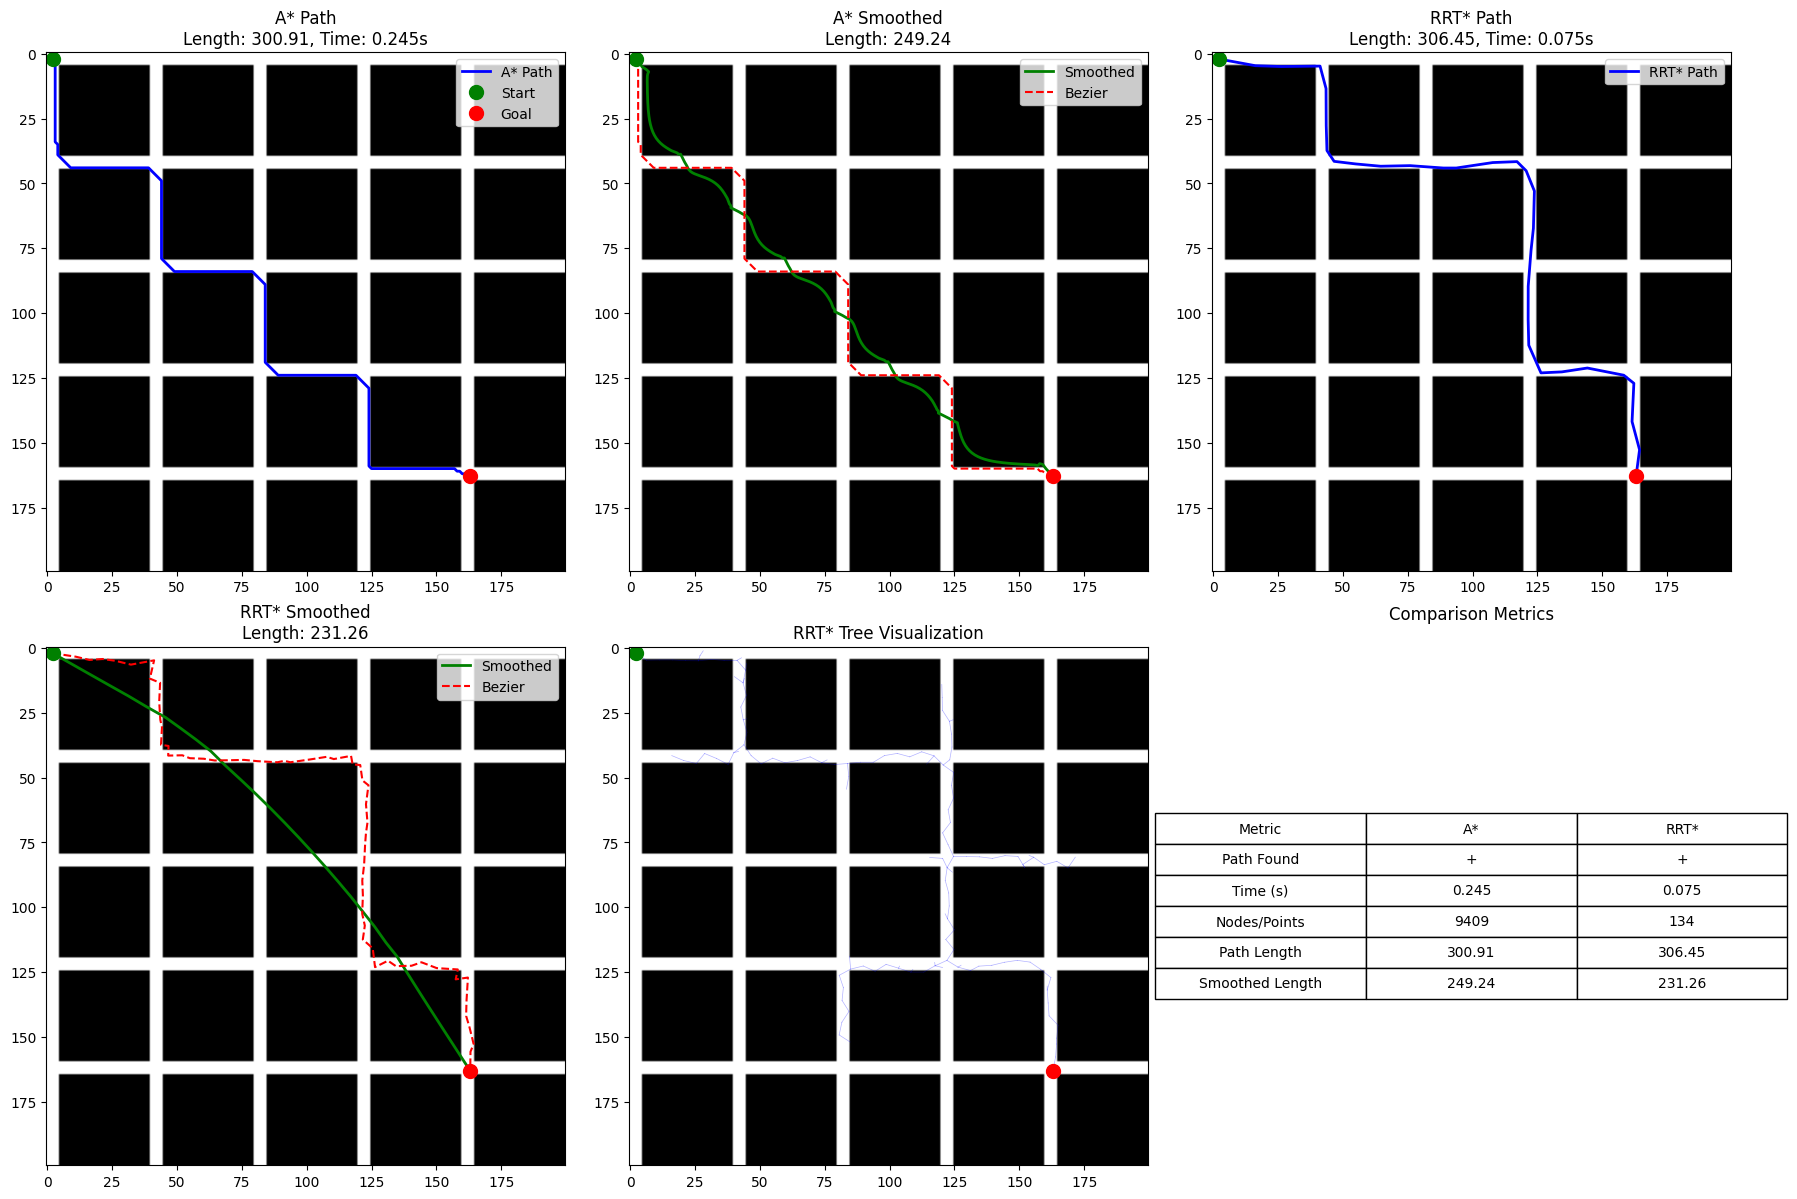

In [25]:
# Запускаем эксперимент
grid, start, goal = map_selection(selected_map= 'map_maze.png')

analyzer = PathPlanningAnalyzer(grid)
results = analyzer.run_experiment(start, goal)

# Визуализация результатов
print("\nВизуализация результатов...")
analyzer.visualize(start, goal)

In [26]:
print("\nСоздание анимации...")
analyzer.animate_rrt(start, goal, filename='exp2_rrt_animation.gif', fps=15)


Создание анимации...
Анимация сохранена: exp2_rrt_animation.gif


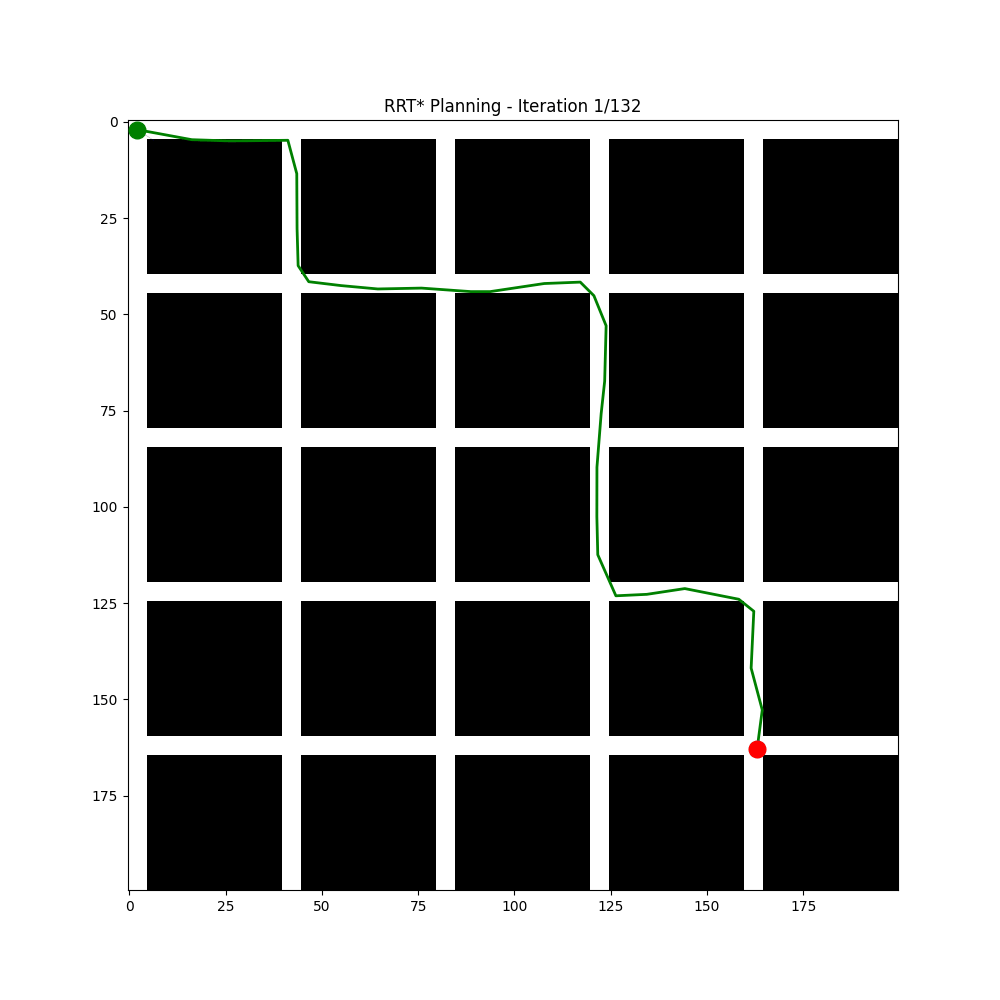

In [29]:
display(ImageIpython(filename='exp2_rrt_animation.gif'))

#### 3.3.3 Тест с картой 3 - Лабиринт


Загрузка карты: map_corridor.png
Сценарий: Узкий вертикальный коридор
Старт: (100, 30)
Цель: (100, 170)
Стартовая точка задана верно!
Целевая точка задана верно!
Запуск A*...
Запуск RRT*...
Сглаживание путей...

Визуализация результатов...


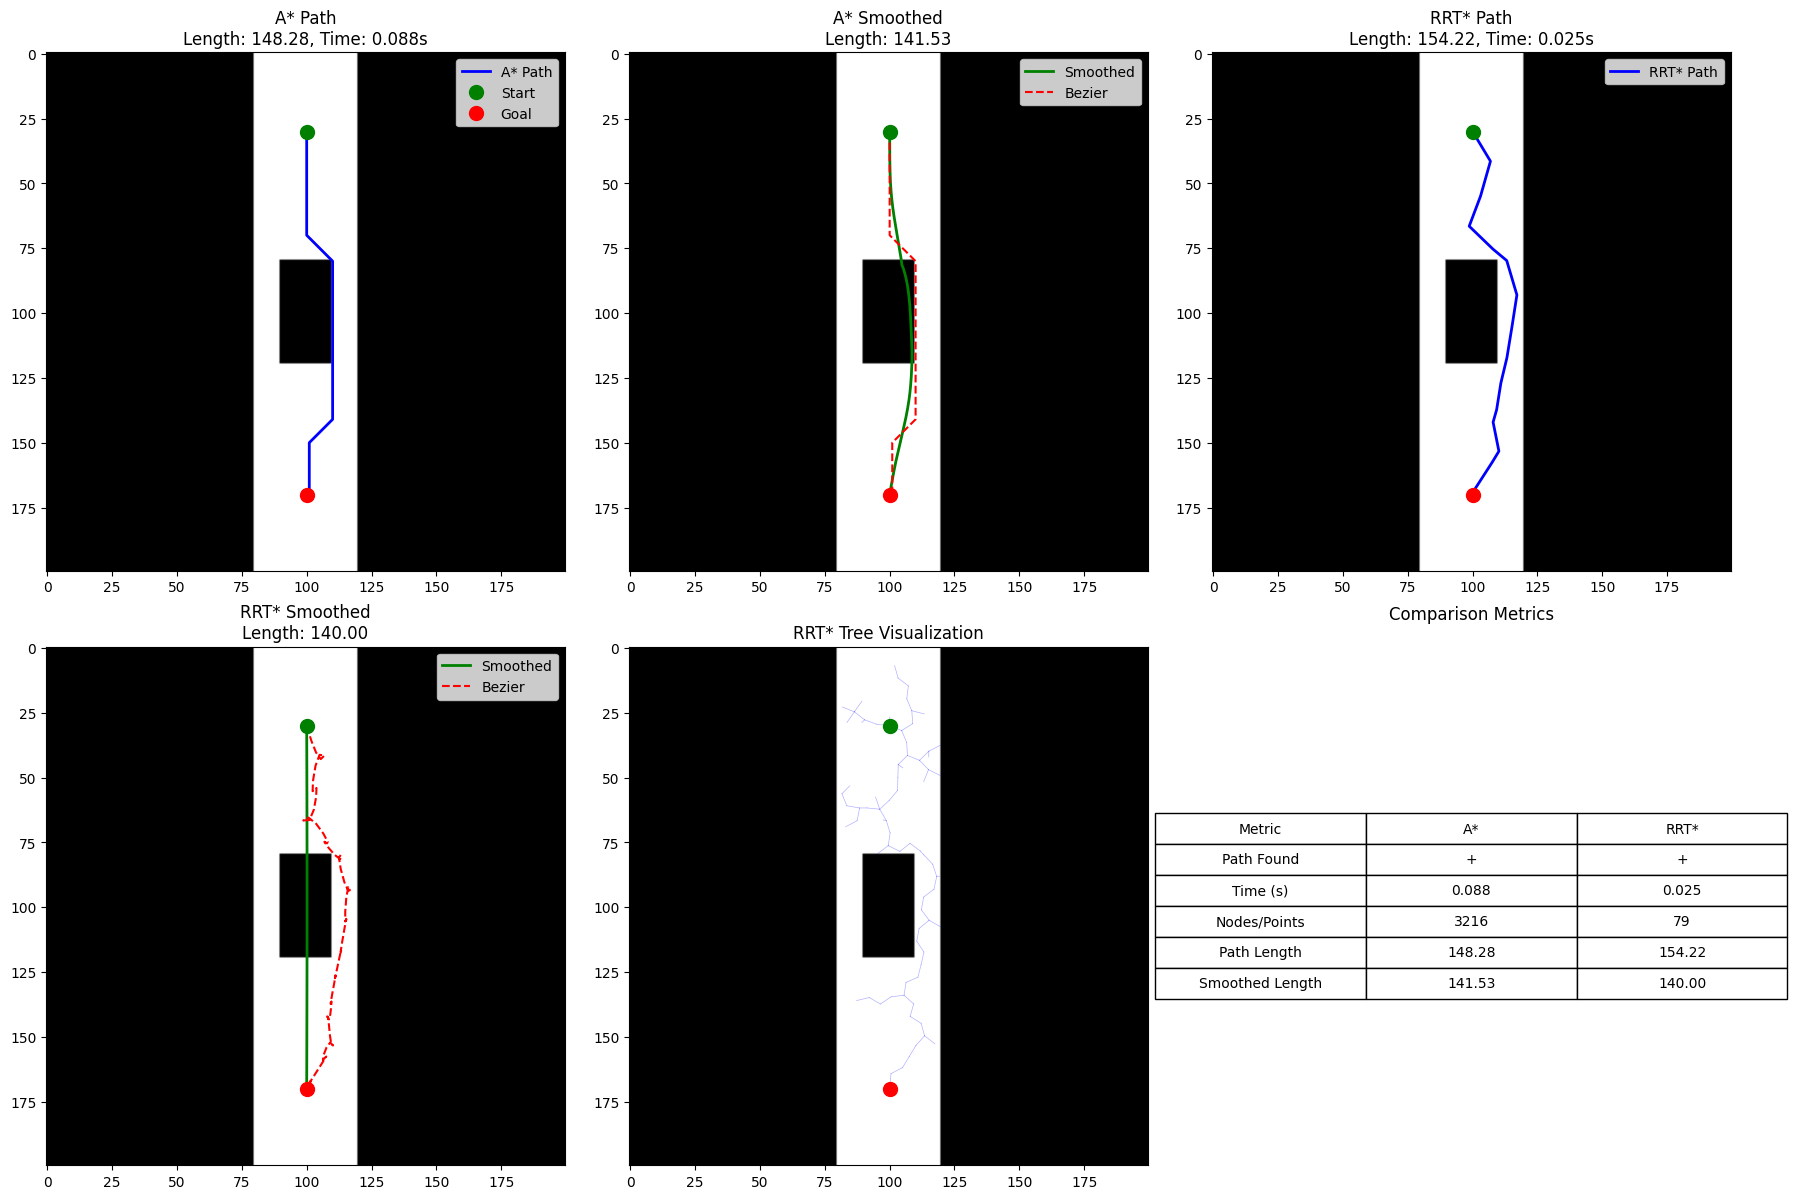

In [27]:
# Запускаем эксперимент
grid, start, goal = map_selection(selected_map= 'map_corridor.png')

analyzer = PathPlanningAnalyzer(grid)
results = analyzer.run_experiment(start, goal)

# Визуализация результатов
print("\nВизуализация результатов...")
analyzer.visualize(start, goal)

In [28]:
print("\nСоздание анимации...")
analyzer.animate_rrt(start, goal, filename='exp3_rrt_animation.gif', fps=15)


Создание анимации...
Анимация сохранена: exp3_rrt_animation.gif


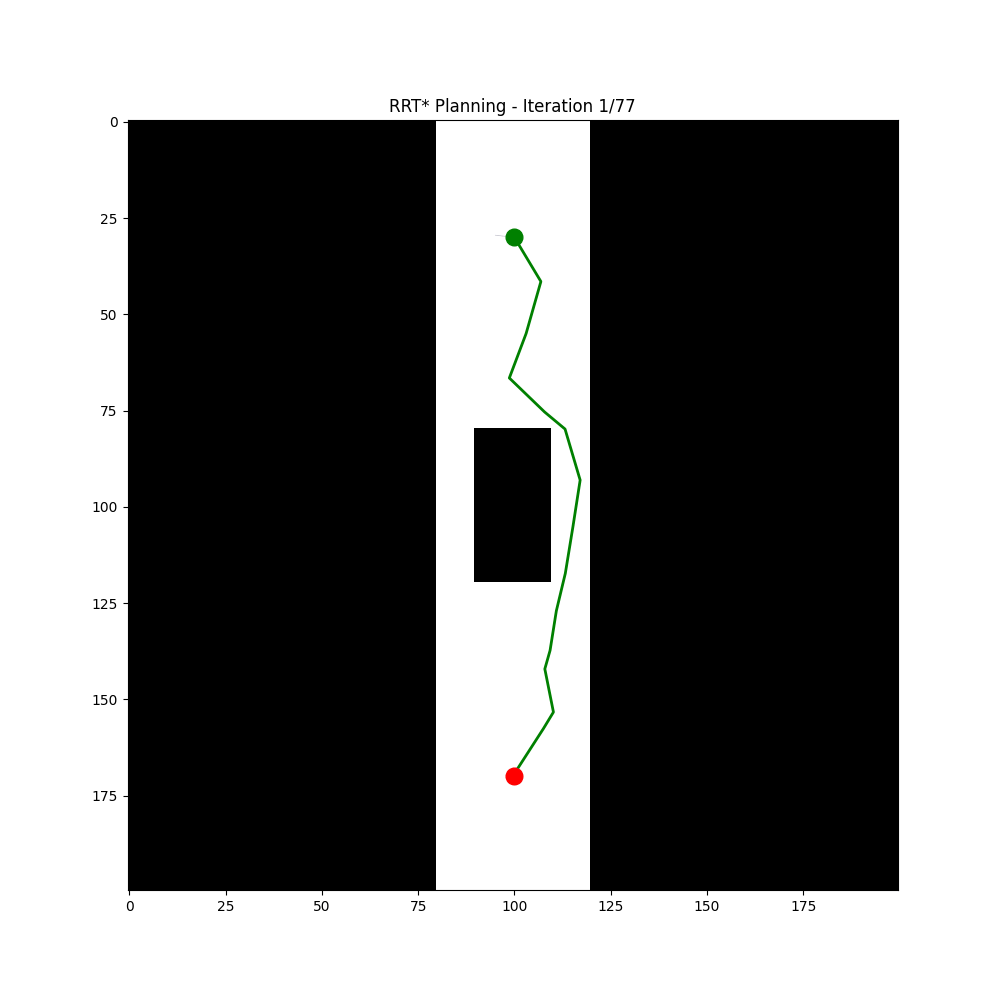

In [30]:
display(ImageIpython(filename='exp3_rrt_animation.gif'))

## Вывод о результатах работы

На основе представленных результатов можно сделать следующие выводы о сравнении алгоритмов A* и RRT*:

**Основные различия между методами:**

1. Производительность и скорость:
- **RRT*** работает значительно быстрее: 0.073с против 0.516с у A* (в 7 раз быстрее)
- Это объясняется тем, что RRT* исследует пространство выборочно, в то время как A* перебирает значительно больше узлов

2. Количество исследованных узлов:
- **A*** исследовал 19,181 узел (детальный перебор на сетке)
- **RRT*** использовал всего 154 узла (случайная выборка)
- Это демонстрирует фундаментальное различие подходов: детерминированный полный перебор vs вероятностный поиск

3. Оптимальность пути:
- **Исходная длина пути**: A* = 238.99, RRT* = 235.87 (RRT* нашел slightly лучший путь)
- **После сглаживания**: A* = 224.21, RRT* = 199.18
- RRT* показал лучшее качество сглаживания (сокращение на 36.69 единиц против 14.78 у A*)

4. Характер траекторий:
- **A*** создает более "угловатые" пути с резкими поворотами (характерно для сеточных алгоритмов)
- **RRT*** генерирует более плавные траектории, которые лучше поддаются сглаживанию

5. Визуализация дерева RRT*:
- Показывает вероятностную природу алгоритма с хаотичным расширением дерева
- Дерево покрывает пространство неравномерно, концентрируясь в направлении цели

### **Преимущества каждого метода:**

**A***:
- Гарантирует нахождение оптимального пути (на сетке)
- Полнота алгоритма (всегда найдет путь, если он существует)
- Предсказуемое поведение

**RRT***:
- Высокая скорость работы
- Эффективность в пространствах высокой размерности
- Меньшее использование памяти
- Лучшая приспособленность для кинематических ограничений робота после сглаживания

### **Практическая значимость:**
Для приложений реального времени RRT* предпочтительнее благодаря скорости, в то время как A* подходит для задач, где критична гарантированная оптимальность на сетке.
